# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/thieu1995/csv-files/main/data/pandas/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [ ]:
chipo = pd.read_csv("chipotle.tsv", sep="\t")
chipo.item_price = chipo.item_price.str.replace("$", "", regex=False).astype(float)


### Step 4. See the first 10 entries

In [ ]:
chipo.head(10)


   order_id  ...  item_price
0         1  ...        2.39
1         1  ...        3.39
2         1  ...        3.39
3         1  ...        2.39
4         2  ...       16.98
5         3  ...       10.98
6         3  ...        1.69
7         4  ...       11.75
8         4  ...        9.25
9         5  ...        9.25

[10 rows x 5 columns]

### Step 5. Create a histogram of the top 5 items bought

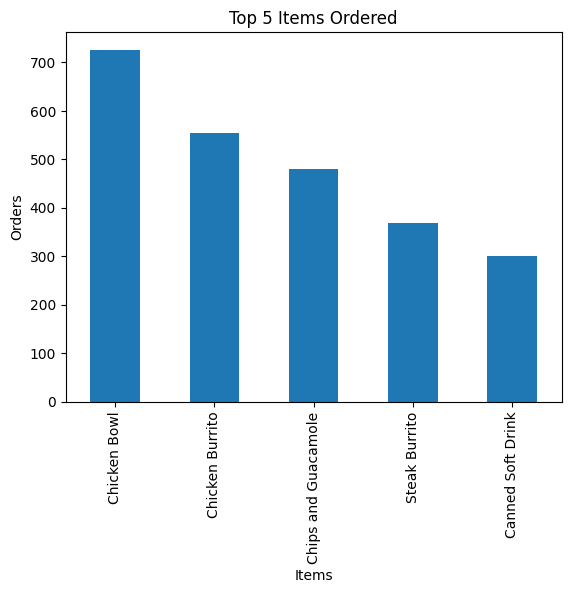

In [ ]:
top_items = chipo.item_name.value_counts().head(5)
top_items.plot(kind="bar")
plt.xlabel("Items")
plt.ylabel("Orders")
plt.title("Top 5 Items Ordered")
plt.show()


### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

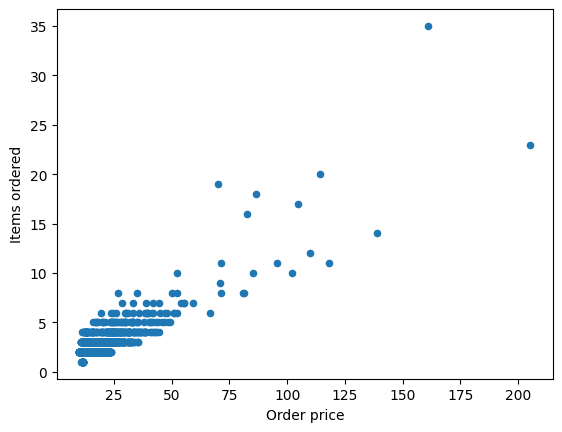

In [ ]:
orders = chipo.groupby("order_id").agg({"quantity": "sum", "item_price": "sum"})
orders.plot.scatter(x="item_price", y="quantity")
plt.xlabel("Order price")
plt.ylabel("Items ordered")
plt.show()


### Step 7. BONUS: Create a question and a graph to answer your own question.

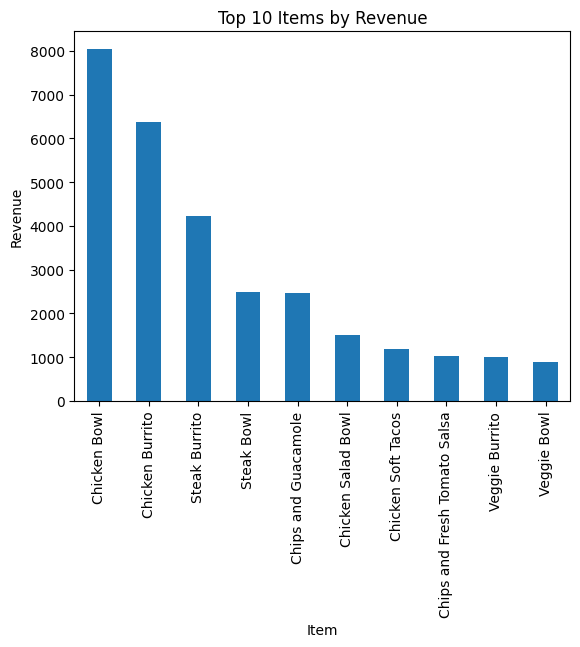

In [ ]:
top_revenue = chipo.assign(revenue=chipo.quantity * chipo.item_price).groupby("item_name").revenue.sum().nlargest(10)
top_revenue.plot(kind="bar")
plt.xlabel("Item")
plt.ylabel("Revenue")
plt.title("Top 10 Items by Revenue")
plt.show()
